In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Hydrological year axis: Sep 1 (day 0) → Aug 31 (day ~365)
_ref = pd.Timestamp("2001-09-01")
TICK_POS = (pd.to_datetime([
    "2001-09-01","2001-10-01","2001-11-01","2001-12-01",
    "2002-01-01","2002-02-01","2002-03-01","2002-04-01",
    "2002-05-01","2002-06-01","2002-07-01","2002-08-01",
]) - _ref).days.tolist()
TICK_LABS = ["Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"]

In [2]:
from pathlib import Path

# Project root - located through the .projectroot marker file, so this
# notebook runs from any checkout location.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / ".projectroot").exists())

nc_path = str(ROOT / "calibration/calibration_data/raw_data/win21/source_data/Win21_all.nc")
ds = xr.open_dataset(nc_path)

df = ds[["HS", "SWE"]].to_dataframe().reset_index()
for col in ["HS", "SWE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Bulk density [kg m⁻³] = SWE [mm] / HS [m]
df["bulk_density_kg_m3"] = df["SWE"] / df["HS"].replace(0, np.nan)

# Values > 600 kg m⁻³ are physically impossible for natural snowpacks and
# indicate measurement artefacts (ice layers, sensor drift).
high_rho_mask = df["bulk_density_kg_m3"] > 600
df_clean = df.copy()
df_clean.loc[high_rho_mask, ["HS", "SWE", "bulk_density_kg_m3"]] = np.nan

print(f"Records masked (ρ > 600 kg m⁻³): {high_rho_mask.sum()}")
print(f"Stations: {df['station'].nunique()}  |  Time steps: {df['time'].nunique()}")


print(f"Percentage of records masked: {high_rho_mask.sum() / len(df['SWE'].dropna()) * 100:.4f}%")

Records masked (ρ > 600 kg m⁻³): 11
Stations: 15  |  Time steps: 10167
Percentage of records masked: 0.7074%


In [3]:
def iqr_bounds(s):
    q1, q3 = s.dropna().quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Per-variable QC summary on the raw (unfiltered) data
rows = []
for col in ["HS", "SWE", "bulk_density_kg_m3"]:
    valid = df[col].dropna()
    lo, hi = iqr_bounds(df[col])
    n_out = int(((df[col] < lo) | (df[col] > hi)).fillna(False).sum())
    rows.append({
        "variable":   col,
        "n":          valid.size,
        "min":        round(valid.min(), 3),
        "max":        round(valid.max(), 3),
        "mean":       round(valid.mean(), 3),
        "median":     round(valid.median(), 3),
        "iqr_lo":     round(lo, 3),
        "iqr_hi":     round(hi, 3),
        "n_outliers": n_out,
    })

print("Physical range checks (raw data):")
for col in ["HS", "SWE", "bulk_density_kg_m3"]:
    print(f"  {col} ≤ 0: {int((df[col] <= 0).sum())}")
print()
display(pd.DataFrame(rows))

# Extreme density values — almost certainly measurement artefacts
display(
    df.loc[df["bulk_density_kg_m3"] > 1000, ["station", "time", "bulk_density_kg_m3"]]
    .sort_values("bulk_density_kg_m3")
    .rename(columns={"bulk_density_kg_m3": "ρ [kg m⁻³]"})
)



Physical range checks (raw data):
  HS ≤ 0: 32271
  SWE ≤ 0: 0
  bulk_density_kg_m3 ≤ 0: 0



,variable,n,min,max,mean,median,iqr_lo,iqr_hi,n_outliers
0,HS,52809,0.000,3.300000,0.177000,0.0,-0.375,0.625,5505
1,SWE,1555,5.000,1015.000000,144.572998,115.0,-133.250,392.750,51
2,bulk_density_kg_m3,1555,59.091,2542.856934,266.308990,250.0,24.437,492.604,34


,station,time,ρ [kg m⁻³]
97742,9,2008-03-31,1080.000000
97721,9,2008-03-10,1433.333374
99198,9,2012-03-26,2542.857178


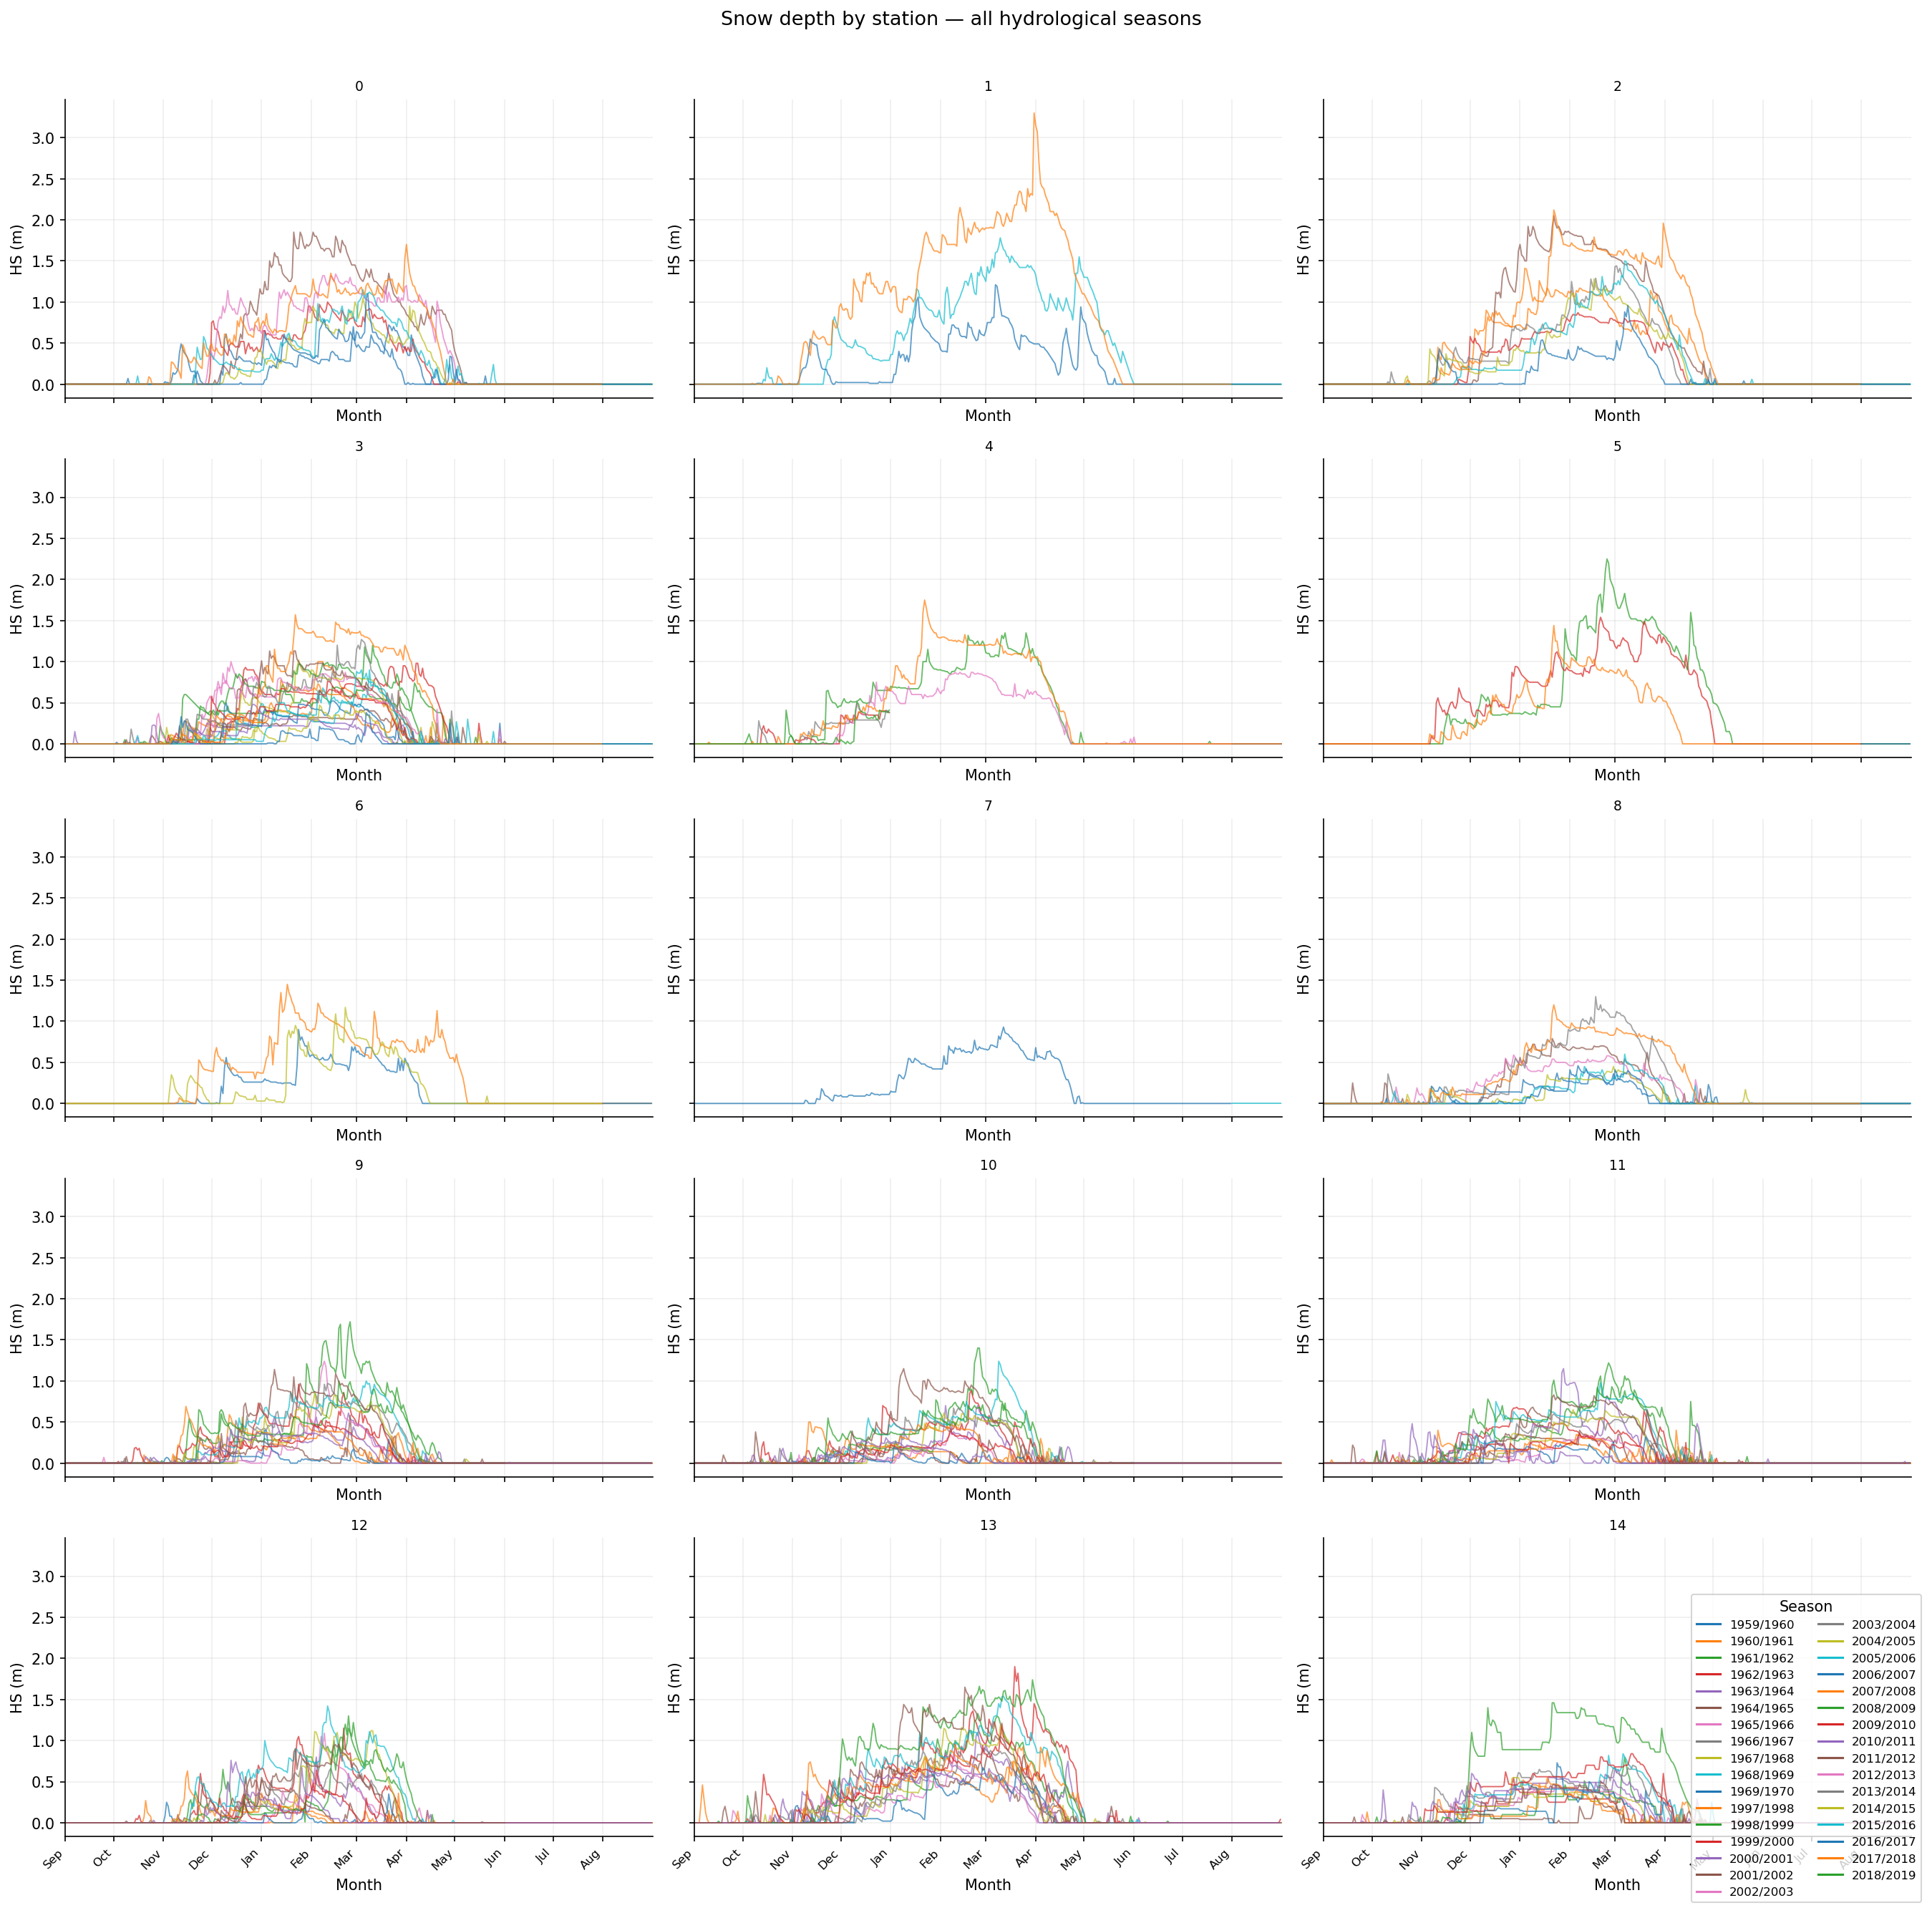

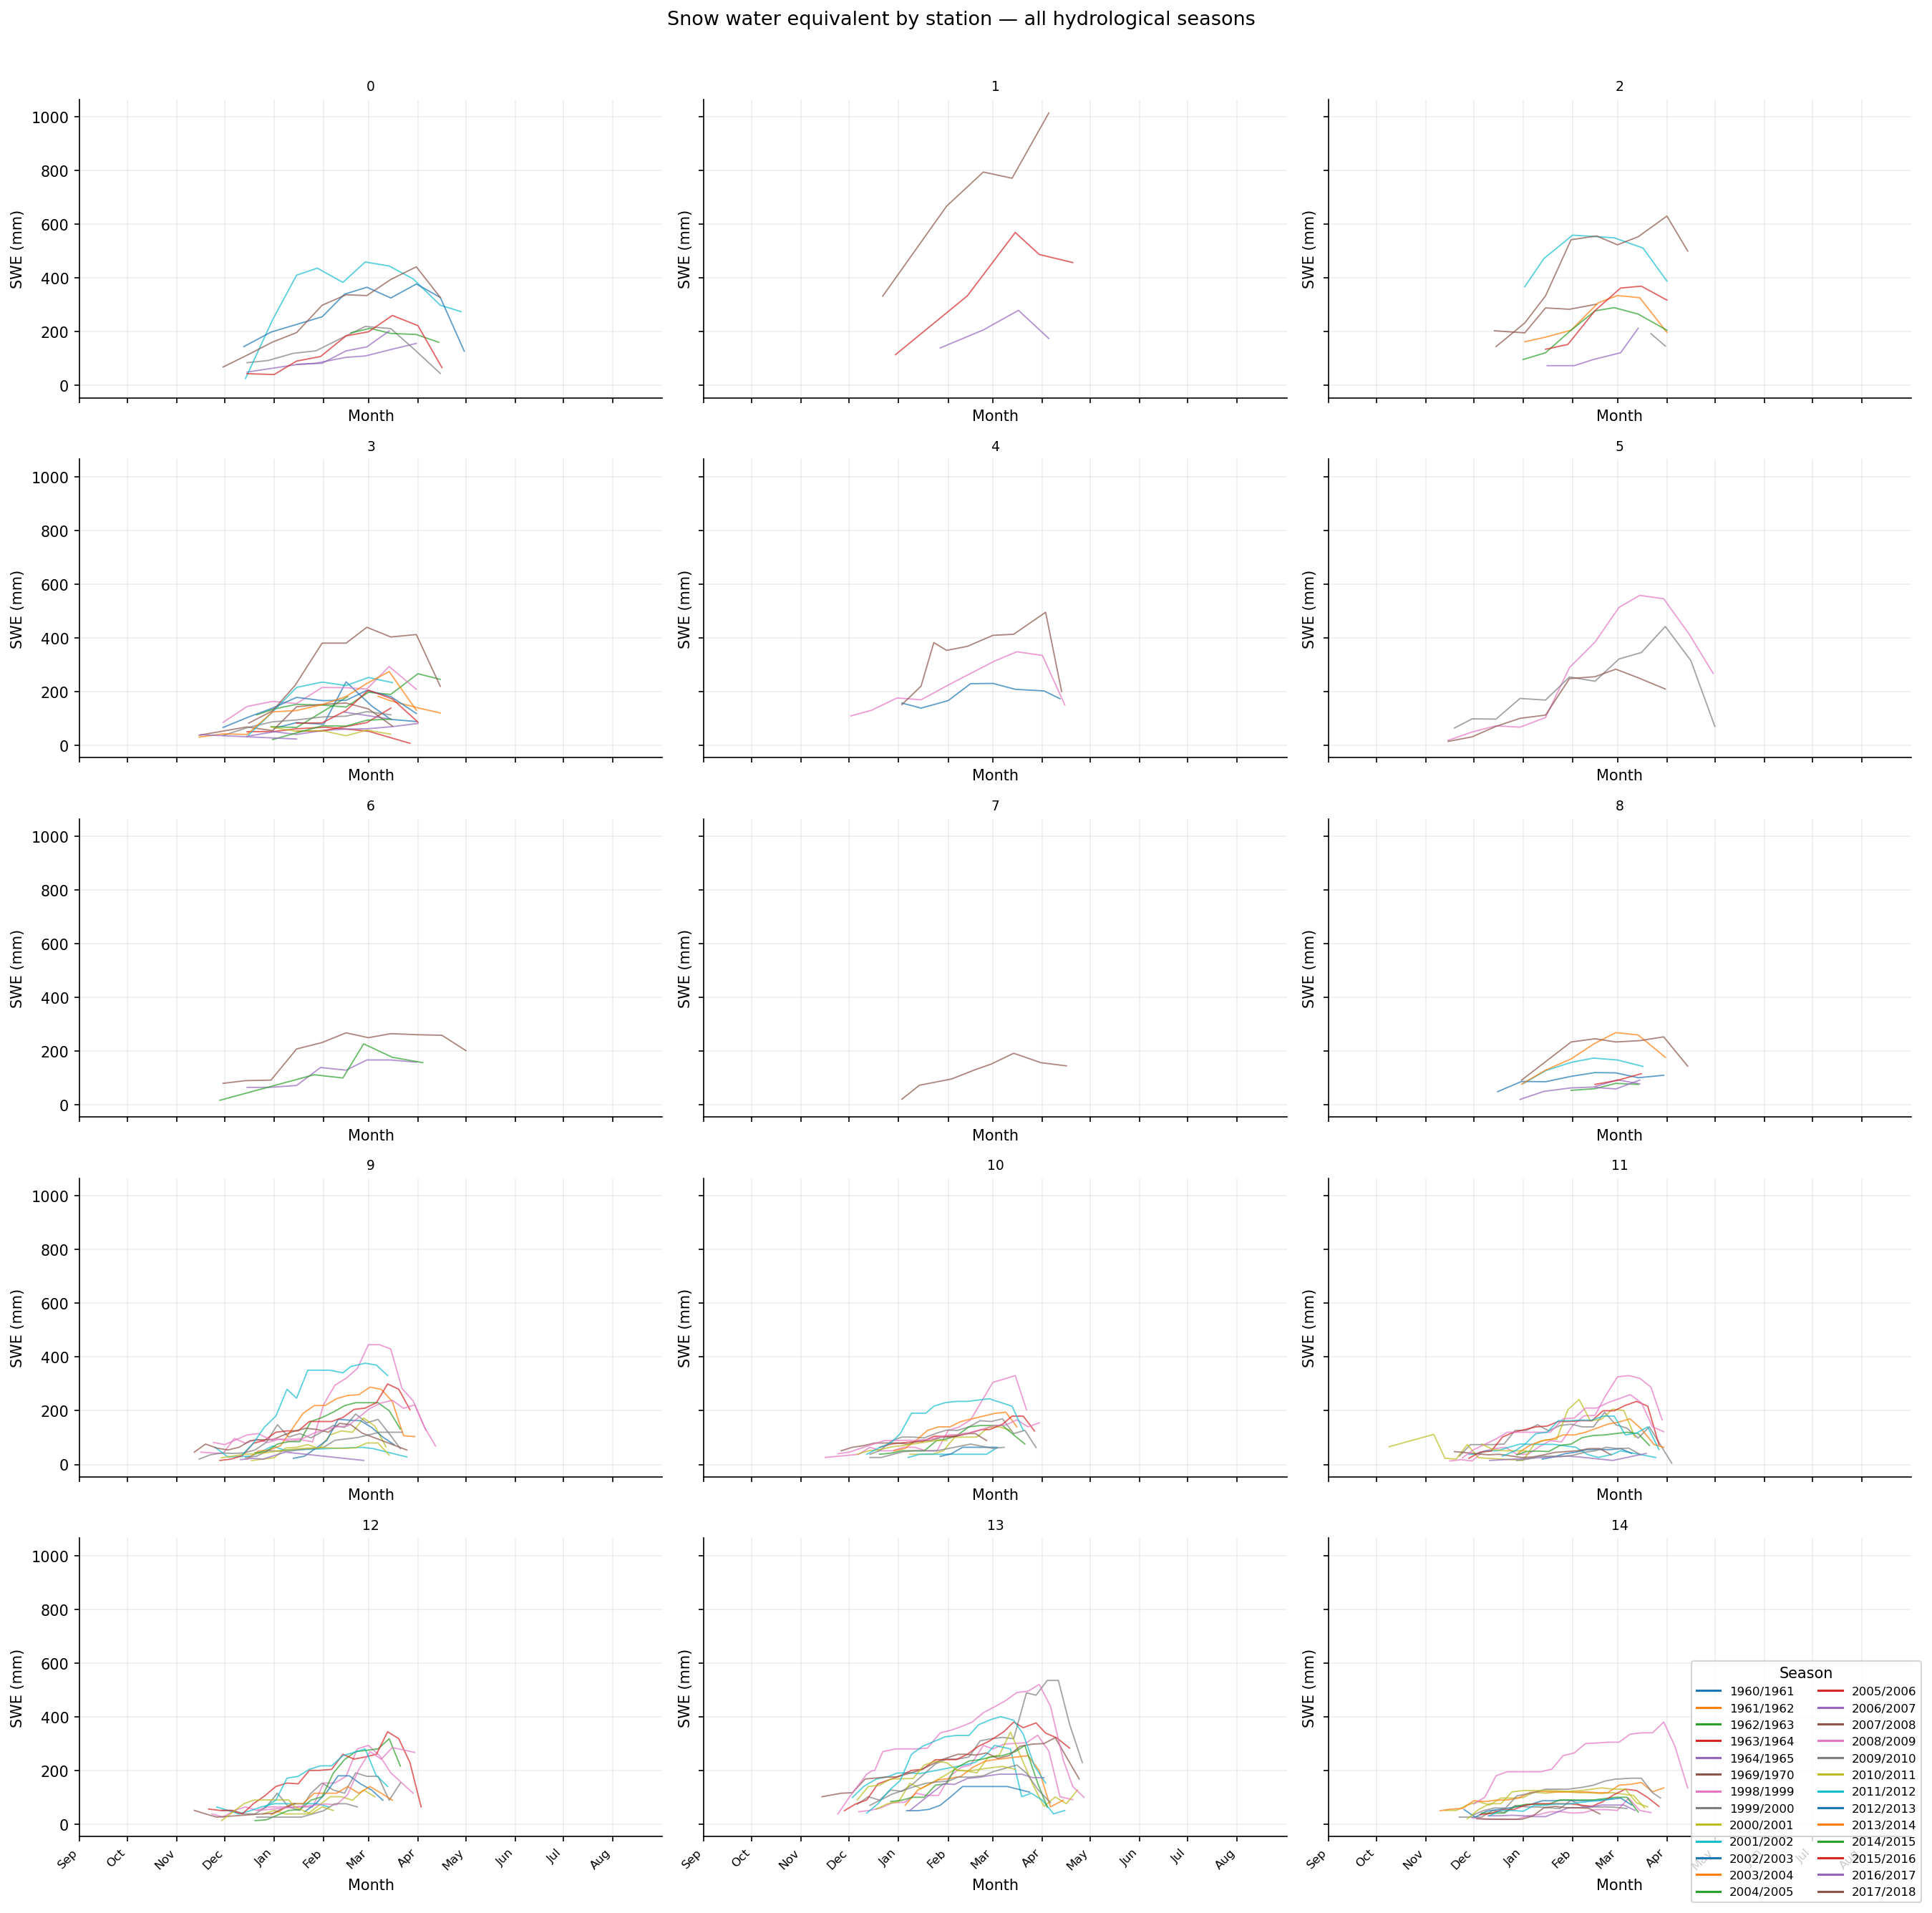

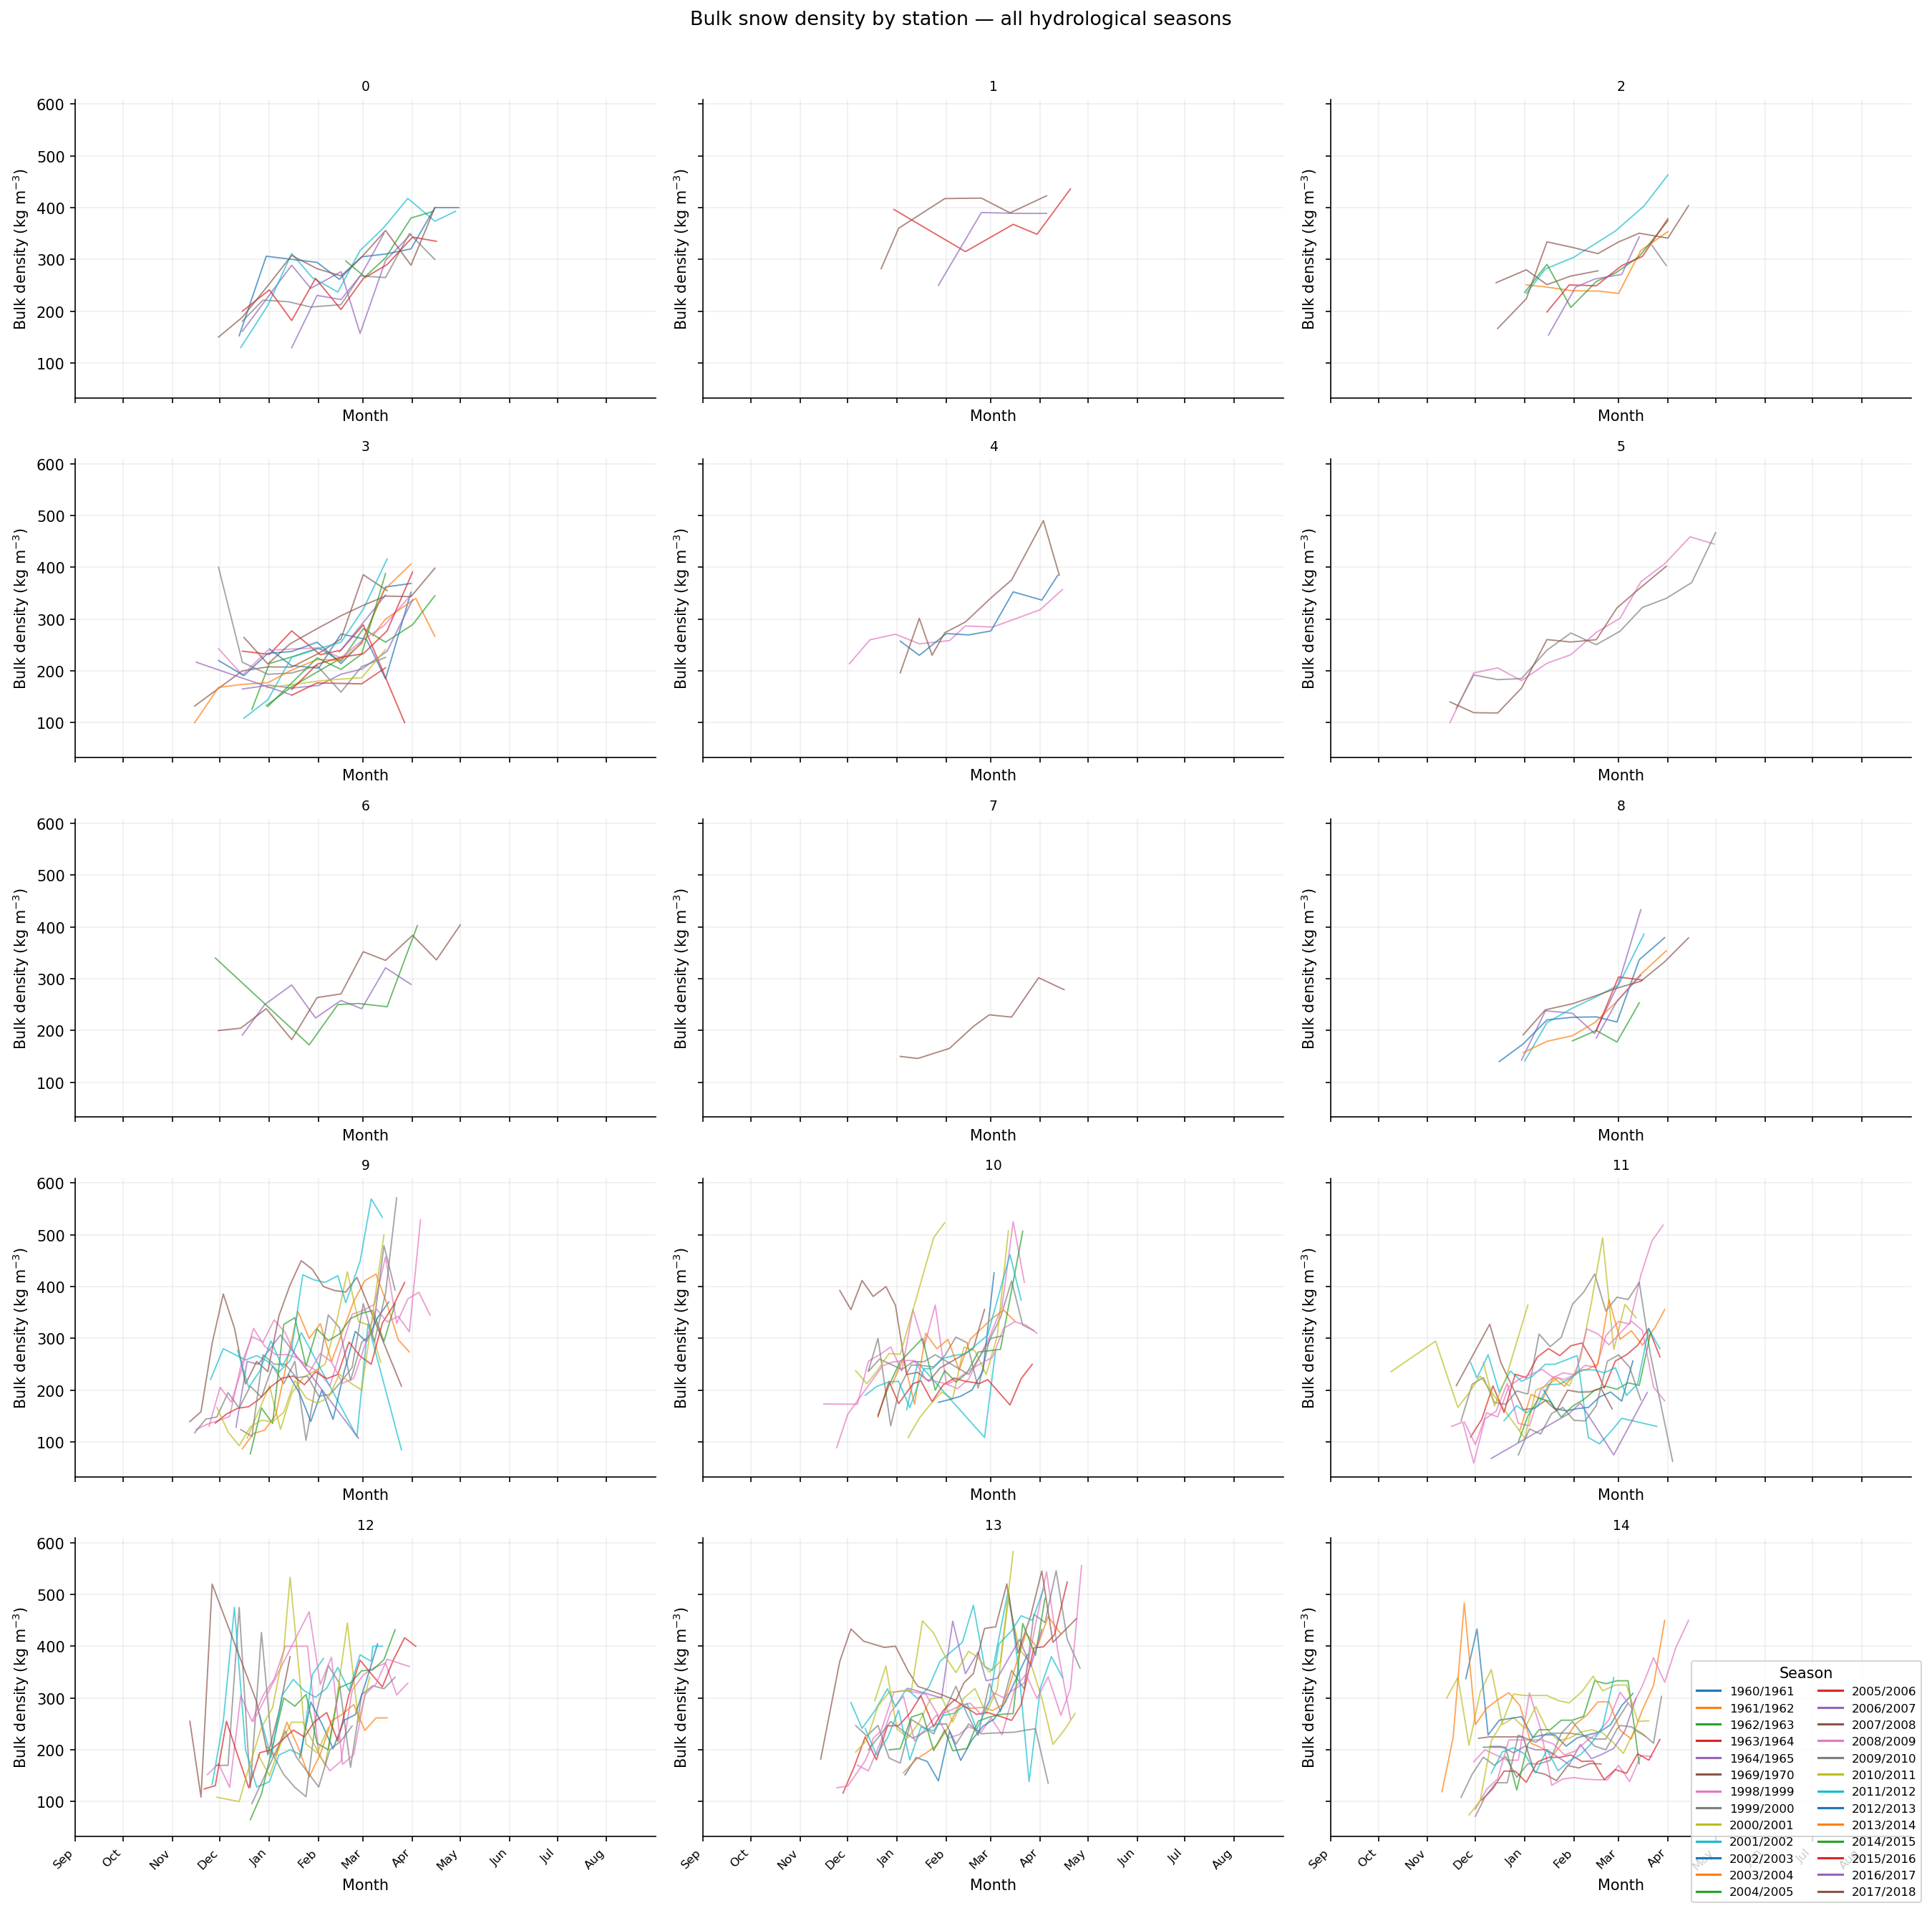

In [4]:
def add_hydro_season(d, value_col):
    """Return copy of d with 'season' label and 'season_day' (Sep 1 = 0) added."""
    d = d[["station", "time", value_col]].dropna(subset=[value_col]).copy()
    yr = np.where(d["time"].dt.month >= 9, d["time"].dt.year, d["time"].dt.year - 1)
    d["season"]     = yr.astype(str) + "/" + (yr + 1).astype(str)
    d["season_day"] = (d["time"] - pd.to_datetime(yr.astype(str) + "-09-01")).dt.days
    return d


def plot_seasonal_by_station(df, value_col, ylabel, title):
    """Small-multiple plot: one panel per station, one trace per season."""
    d        = add_hydro_season(df, value_col)
    stations = sorted(d["station"].unique())
    ncols    = 3
    nrows    = int(np.ceil(len(stations) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    # Assign a consistent colour per season across all panels
    seasons_all  = sorted(d["season"].unique())
    season_color = {s: plt.cm.tab10(i % 10) for i, s in enumerate(seasons_all)}

    for i, station in enumerate(stations):
        ax  = axes[i]
        sdf = d[d["station"] == station].sort_values("time")
        for season, g in sdf.groupby("season"):
            ax.plot(g["season_day"], g[value_col], lw=0.9, alpha=0.7,
                    color=season_color[season])
        ax.set_title(str(station).replace("_", " "), fontsize=9)
        ax.grid(True, alpha=0.2)
        ax.set_xlim(0, 365)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    for ax in axes[:len(stations)]:
        ax.set_xticks(TICK_POS)
        ax.set_xticklabels(TICK_LABS, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("Month")
        ax.set_ylabel(ylabel)

    # Legend: one entry per season
    handles = [plt.Line2D([0], [0], color=season_color[s], lw=1.5, label=s)
               for s in seasons_all]
    fig.legend(handles=handles, title="Season", loc="lower right",
               bbox_to_anchor=(1.0, 0.0), fontsize=8, ncol=2)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


plot_seasonal_by_station(df_clean, "HS",
    ylabel="HS (m)",
    title="Snow depth by station — all hydrological seasons")

plot_seasonal_by_station(df_clean, "SWE",
    ylabel="SWE (mm)",
    title="Snow water equivalent by station — all hydrological seasons")

plot_seasonal_by_station(df_clean, "bulk_density_kg_m3",
    ylabel=r"Bulk density (kg m$^{-3}$)",
    title="Bulk snow density by station — all hydrological seasons")

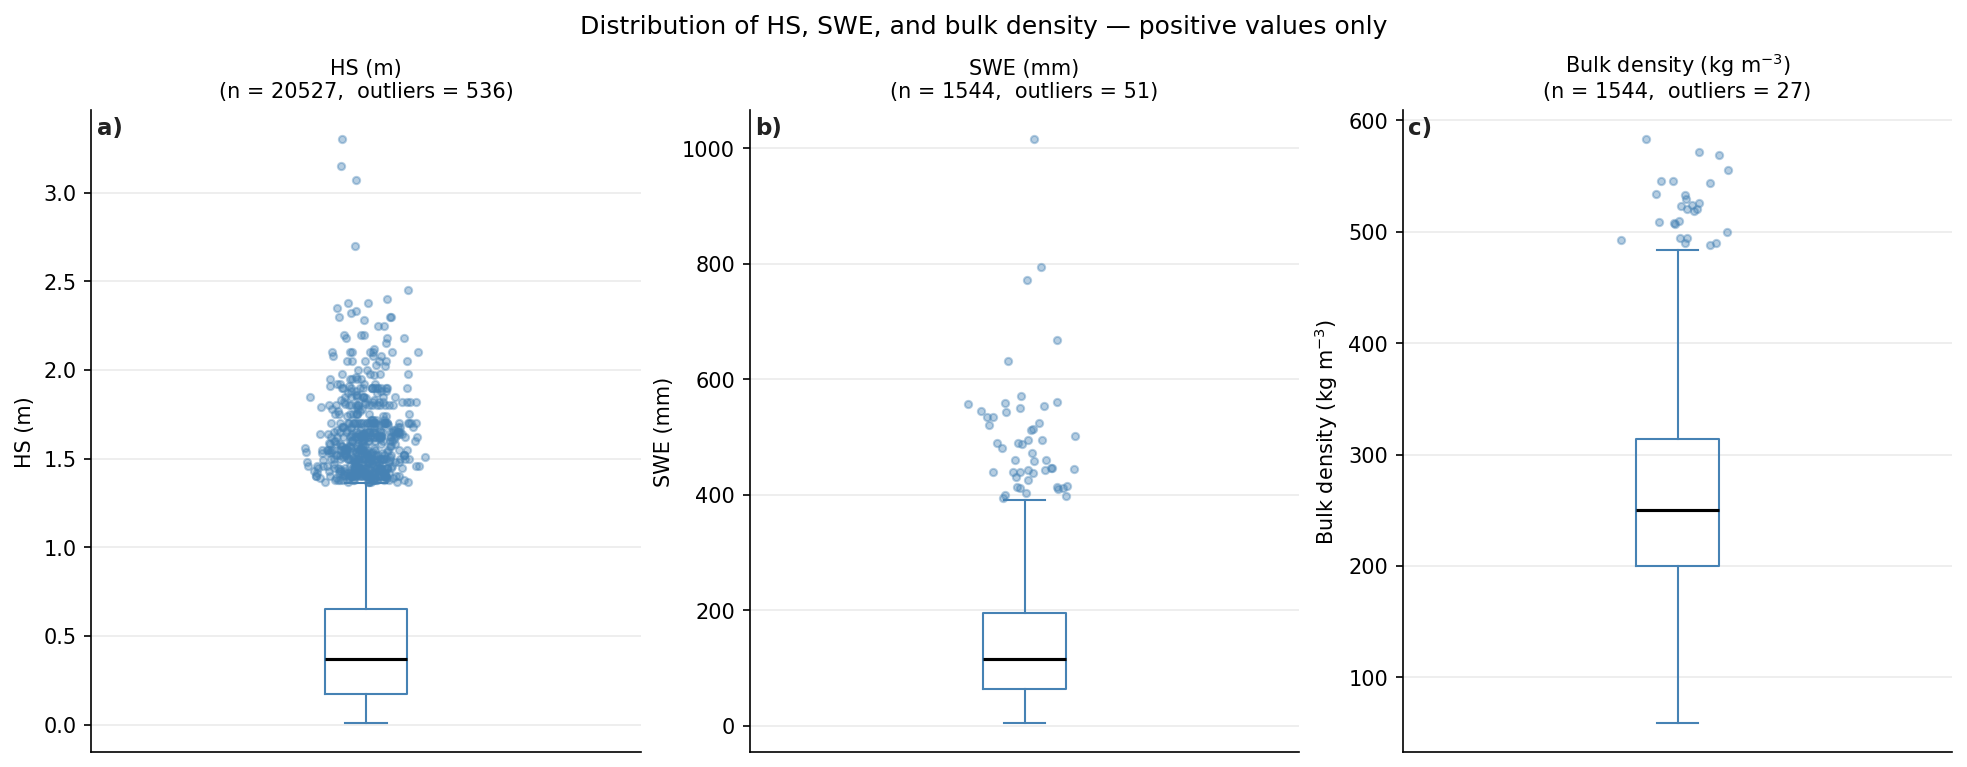

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[3]))  # mt_dsnow root
from plot_style import add_subplot_labels

cols   = ["HS", "SWE", "bulk_density_kg_m3"]
labels = ["HS (m)", "SWE (mm)", r"Bulk density (kg m$^{-3}$)"]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True)

for ax, col, label in zip(axes, cols, labels):
    s = df_clean[col].dropna()
    s = s[s > 0]

    ax.boxplot(
        s.values, vert=True, showfliers=False,
        medianprops  = dict(color="black",    linewidth=1.5),
        boxprops     = dict(color="steelblue"),
        whiskerprops = dict(color="steelblue"),
        capprops     = dict(color="steelblue"),
    )

    # Jitter outlier points so density is visible
    q1, q3  = s.quantile([0.25, 0.75])
    iqr     = q3 - q1
    out     = s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)]
    np.random.seed(0)
    ax.scatter(np.random.normal(1, 0.04, len(out)), out,
               color="steelblue", s=12, alpha=0.4, zorder=3)

    ax.set_title(f"{label}\n(n = {len(s)},  outliers = {len(out)})", fontsize=10)
    ax.set_xticks([])
    ax.set_ylabel(label)
    ax.grid(True, axis="y", alpha=0.25)

fig.suptitle("Distribution of HS, SWE, and bulk density — positive values only", fontsize=12)
add_subplot_labels(axes)
plt.show()

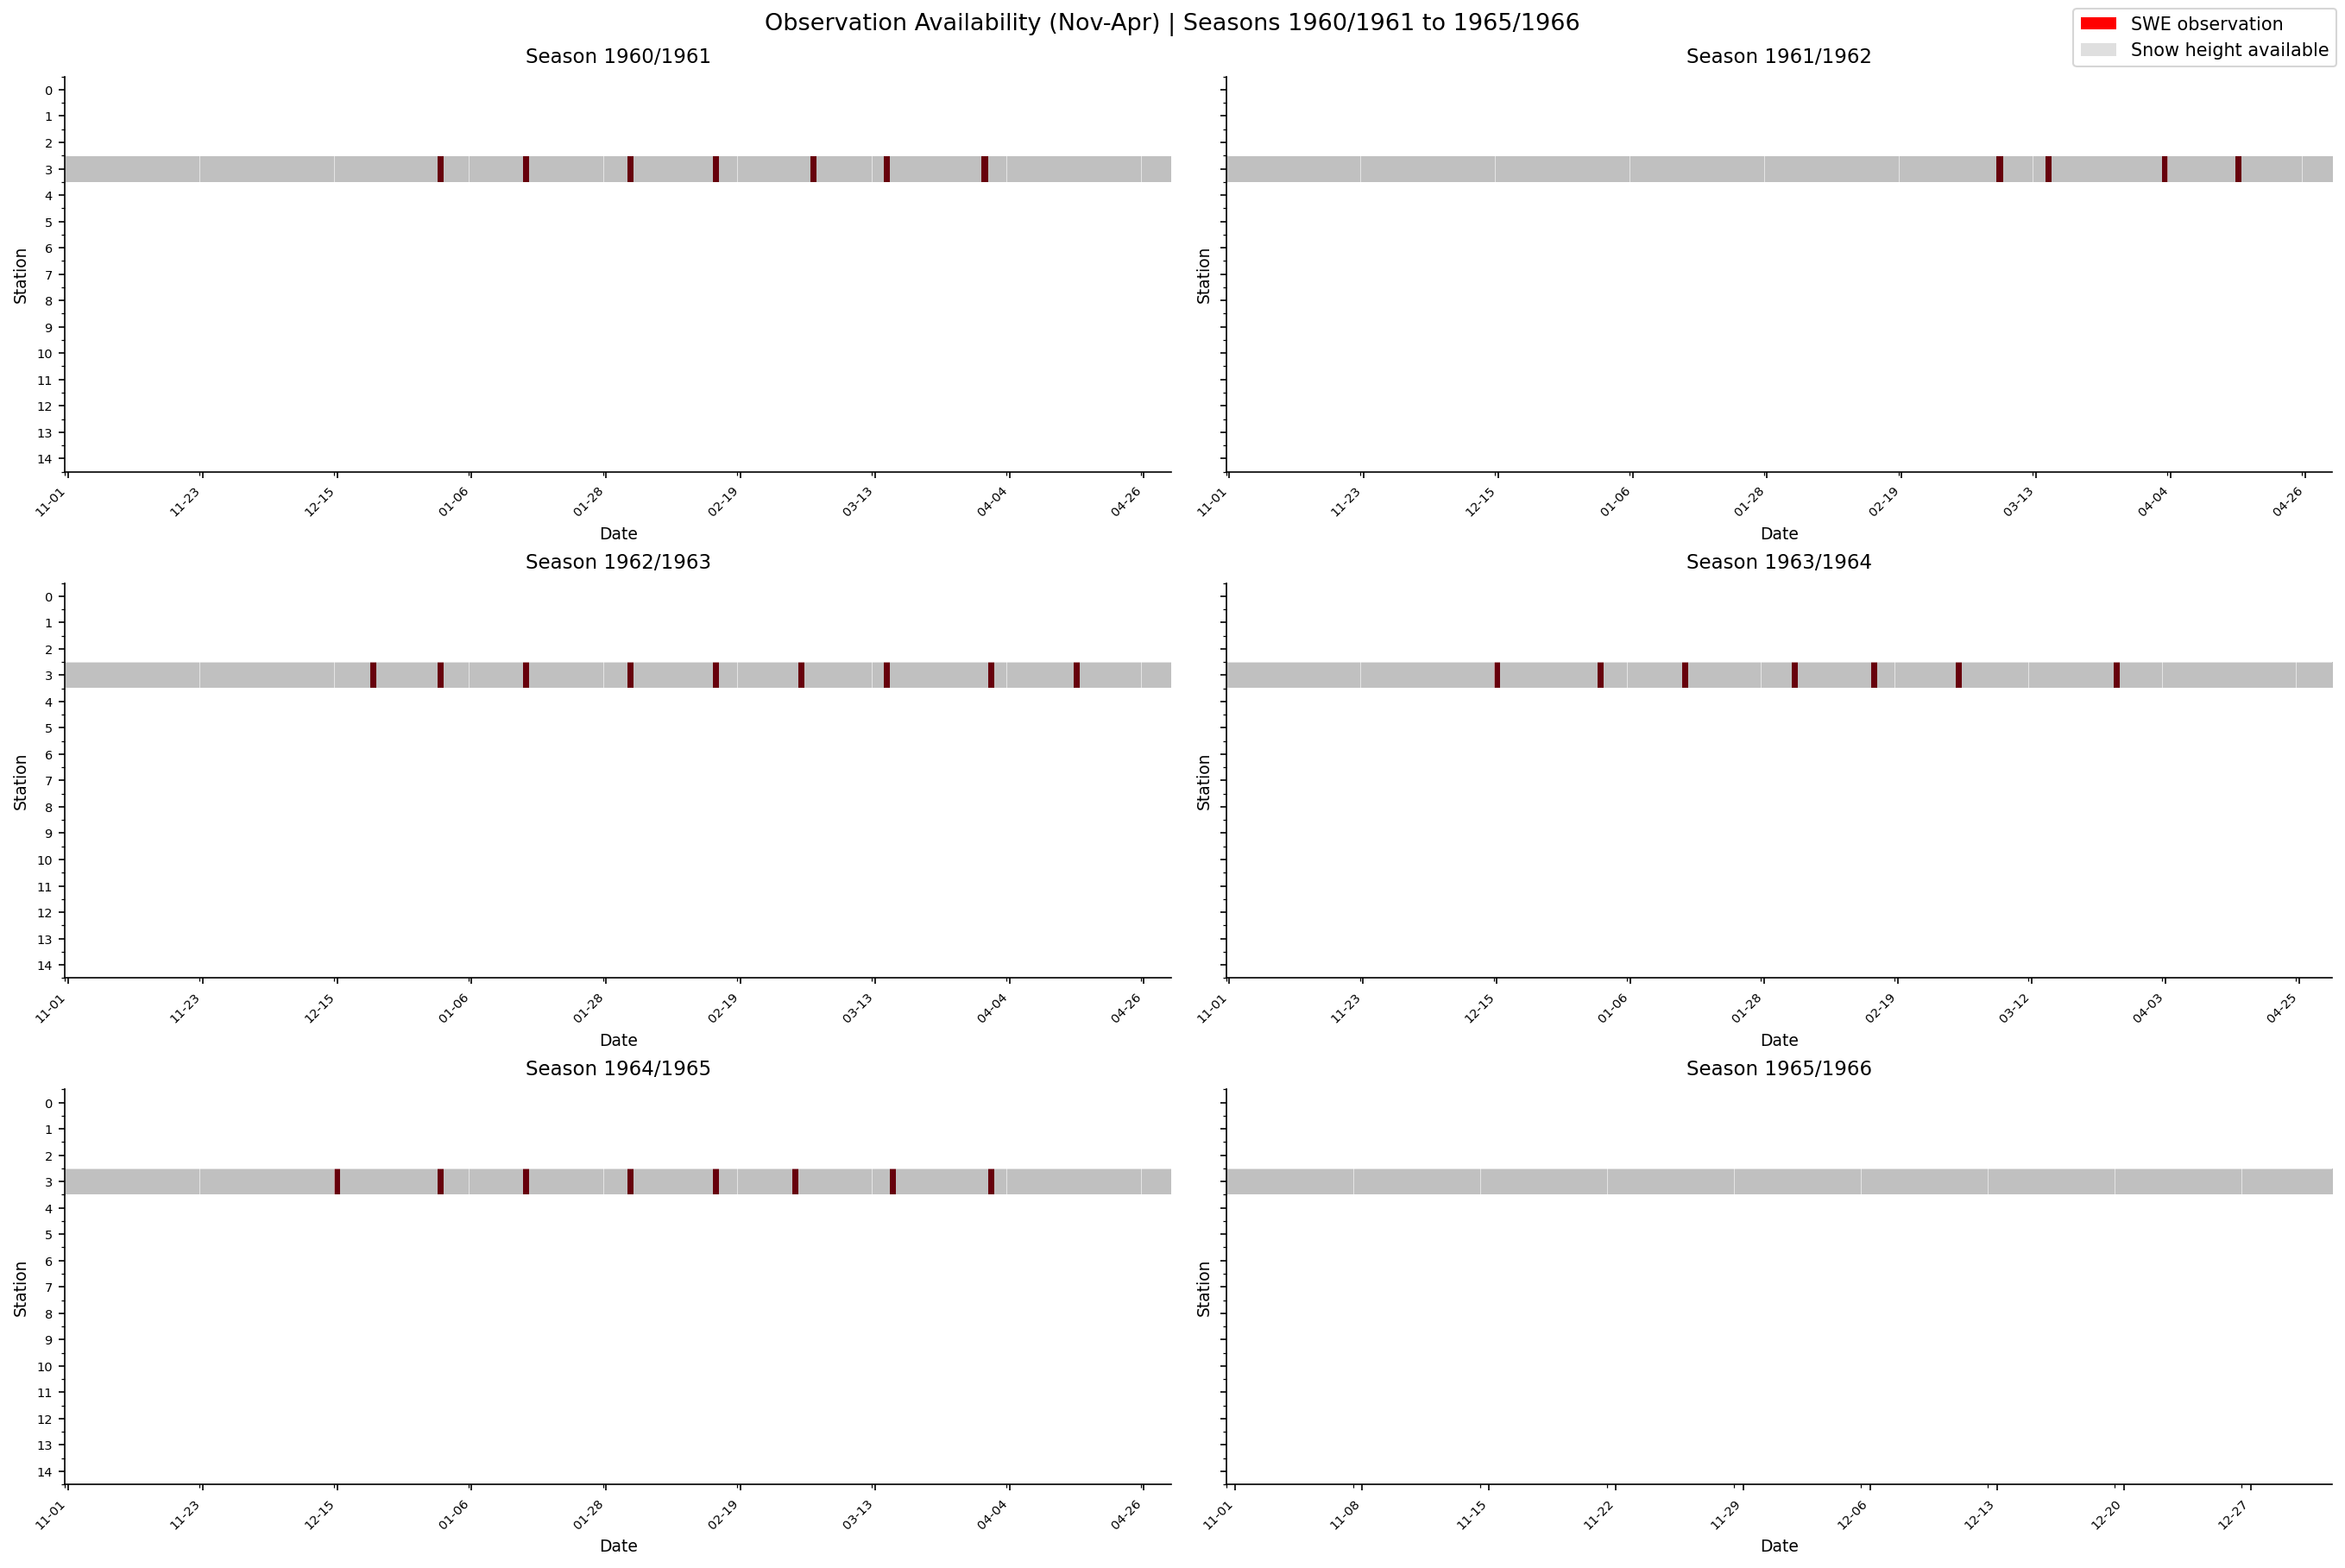

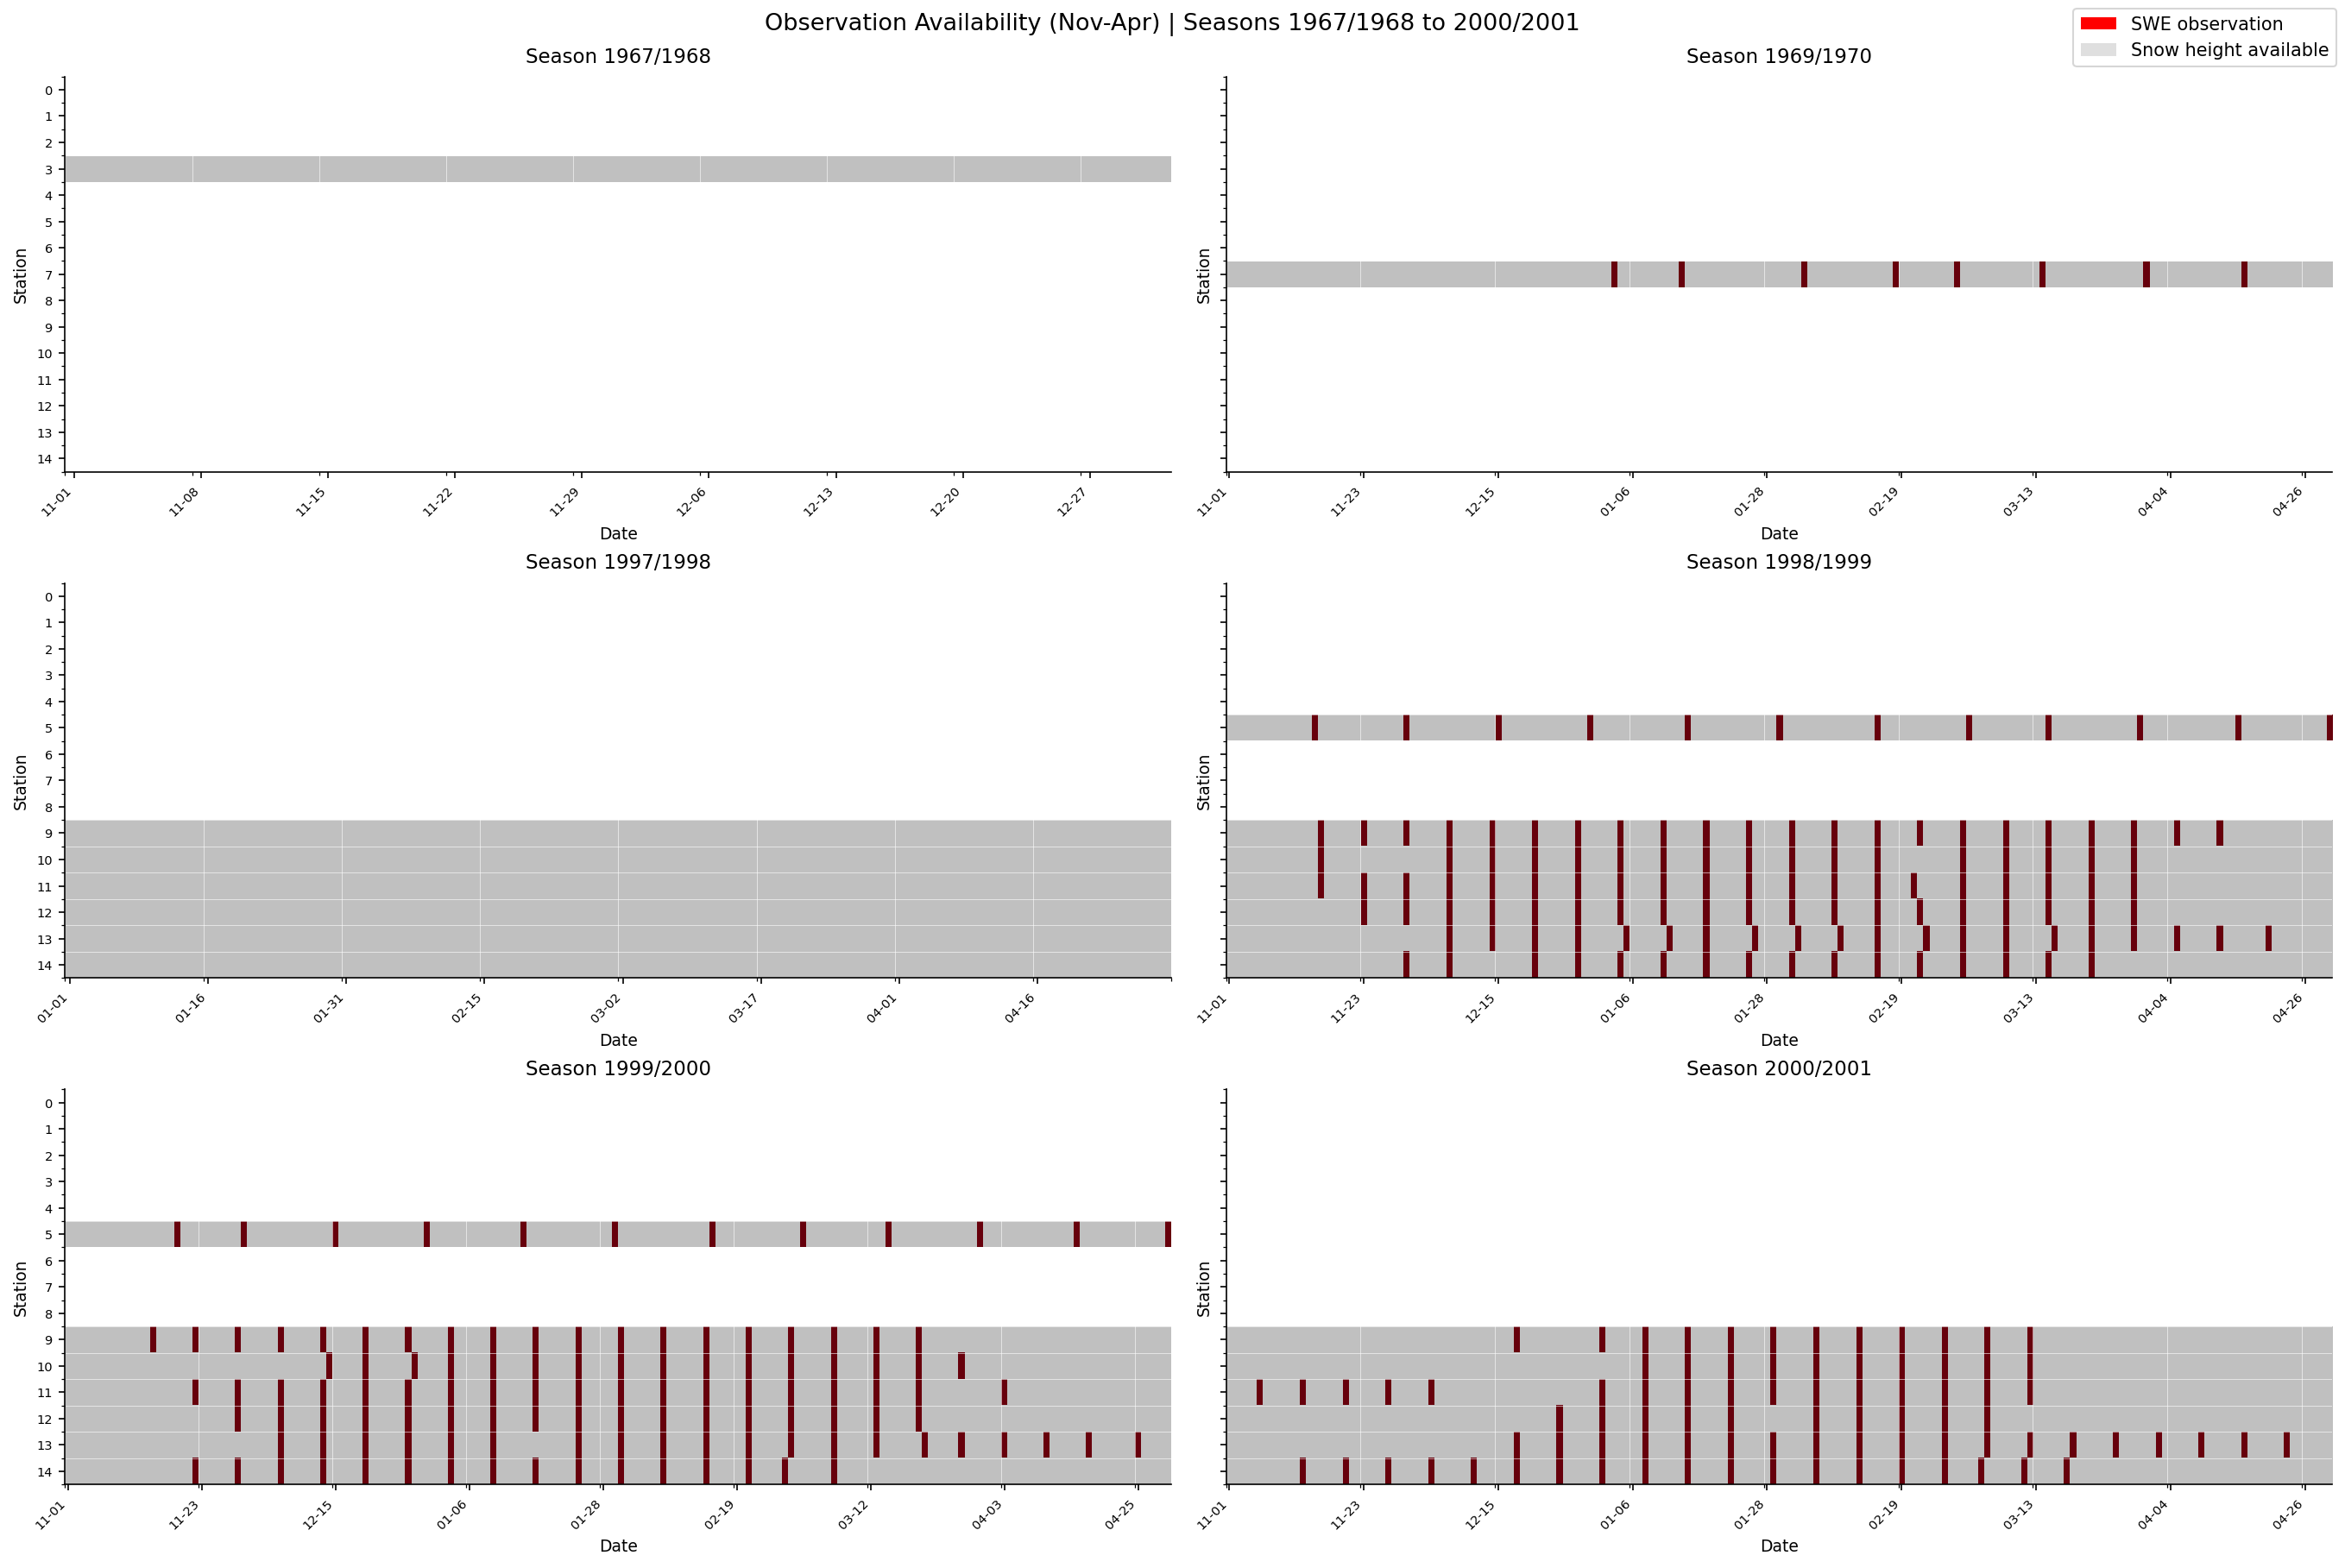

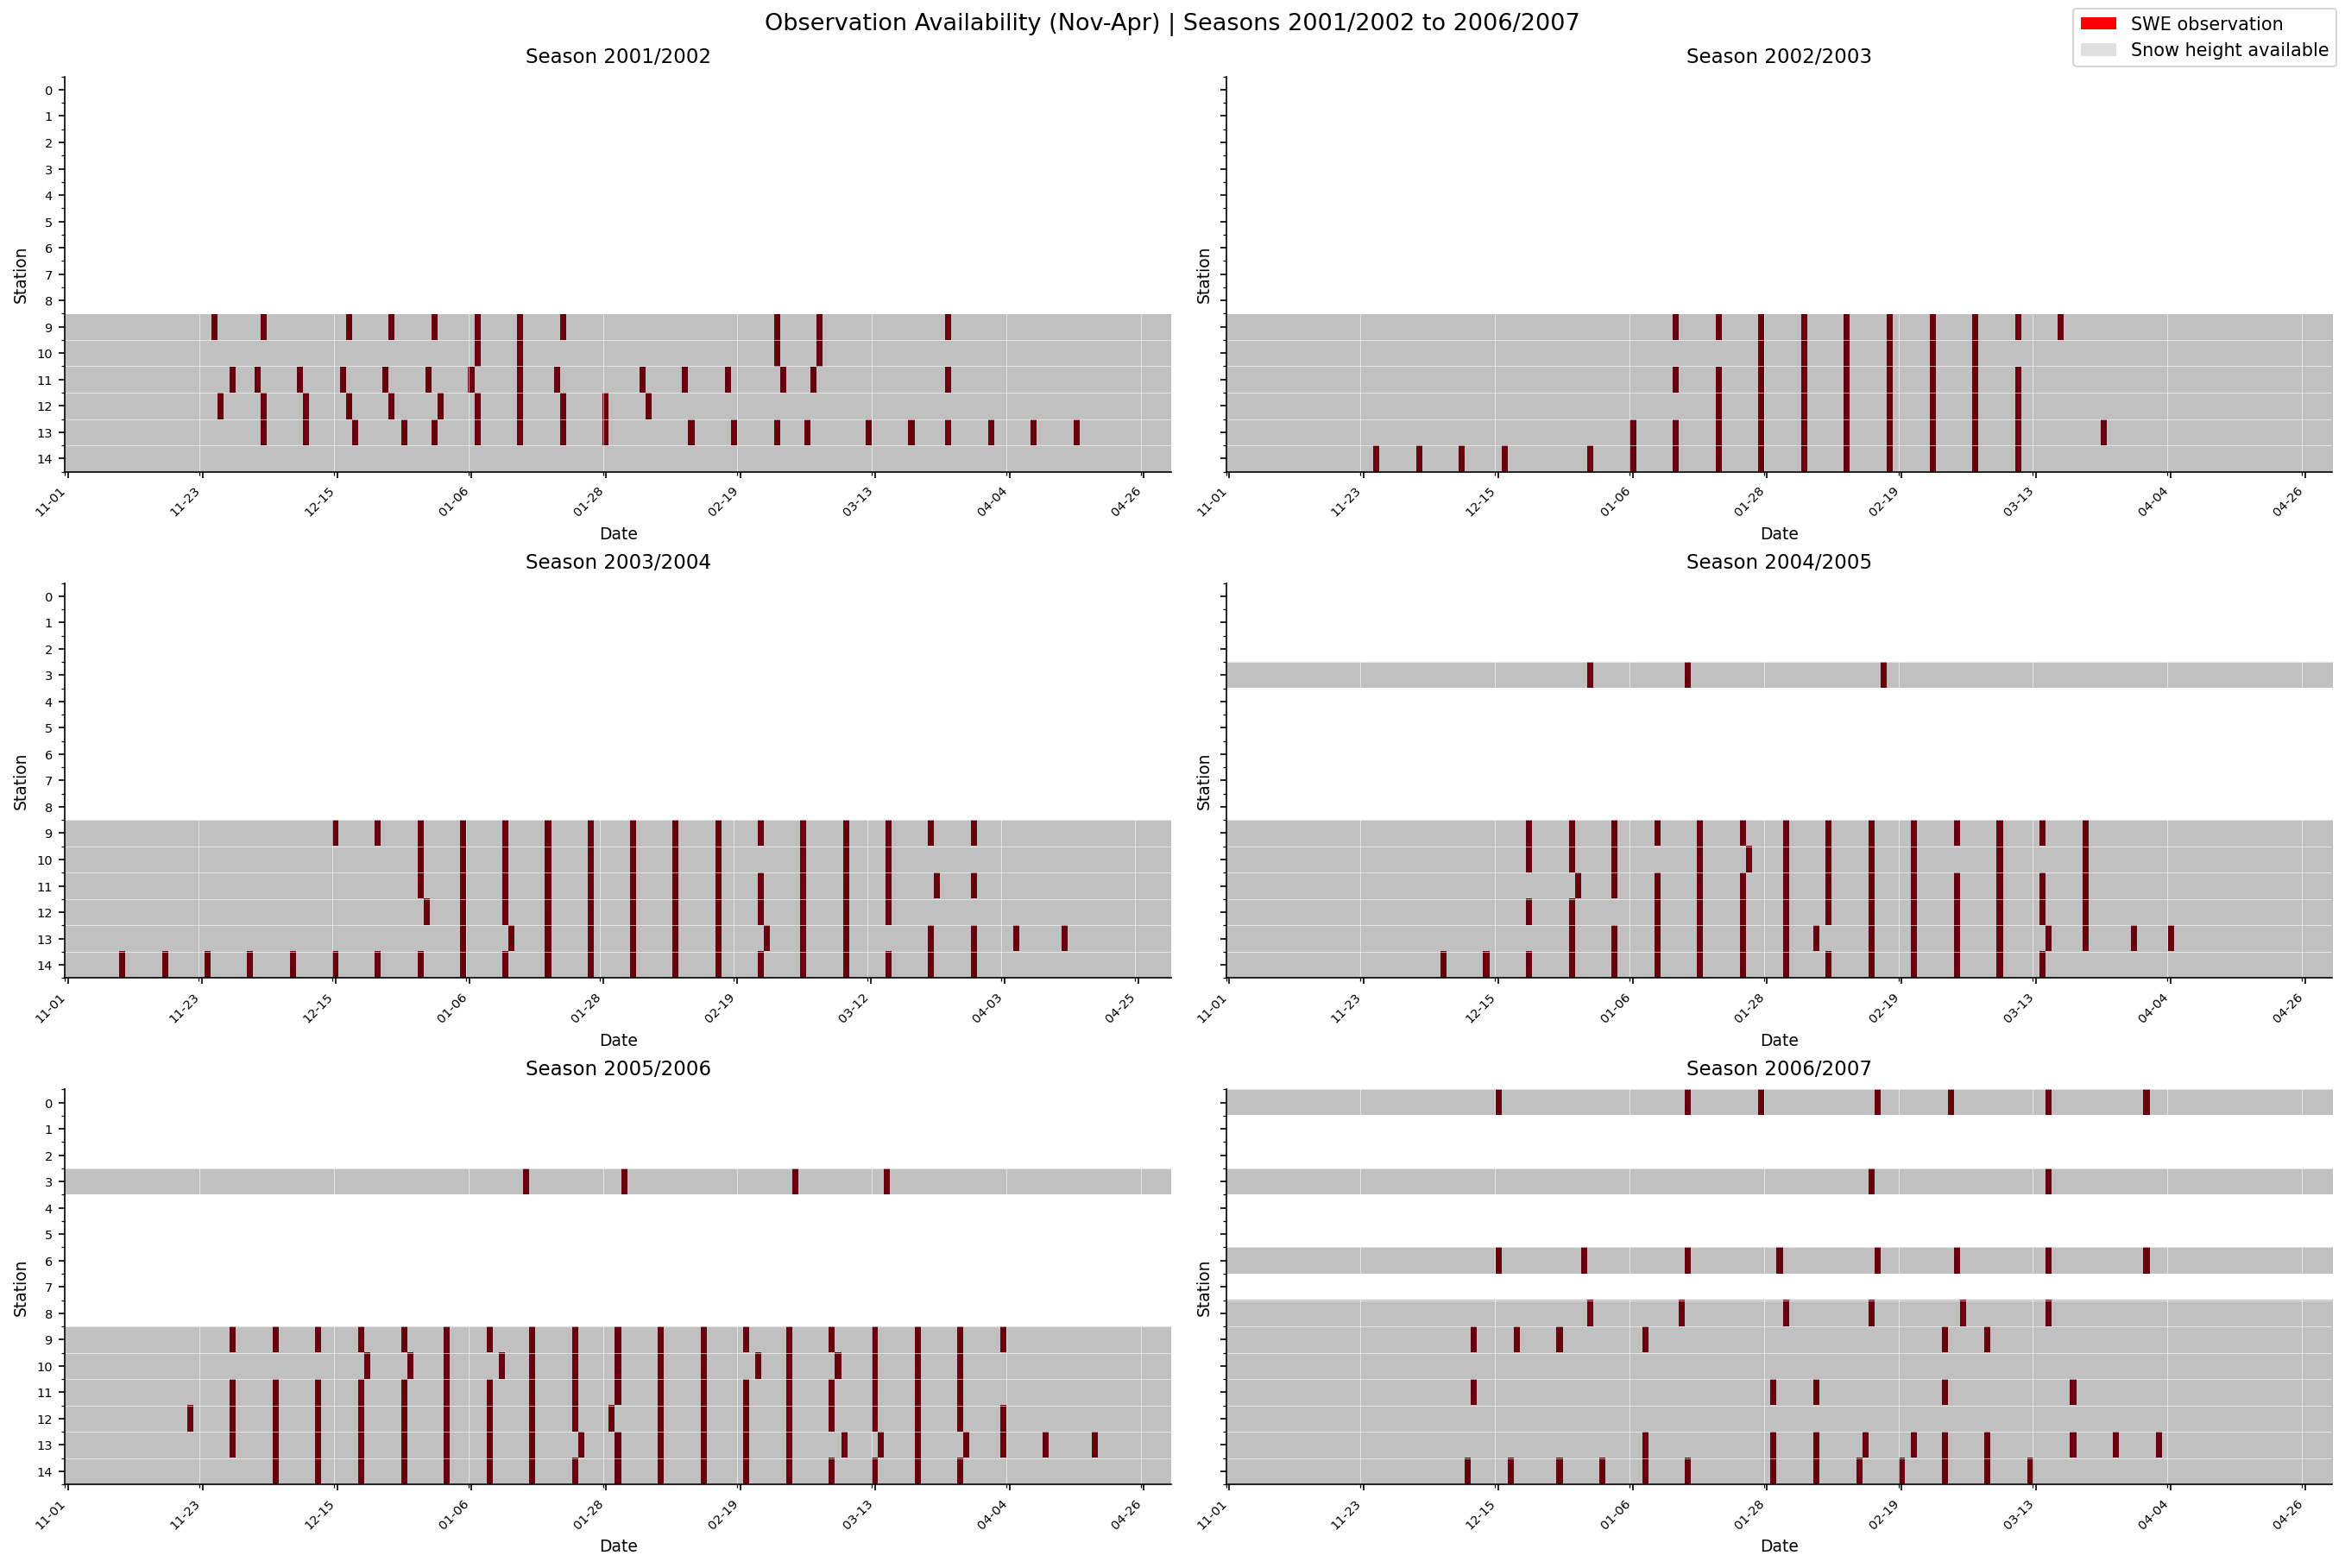

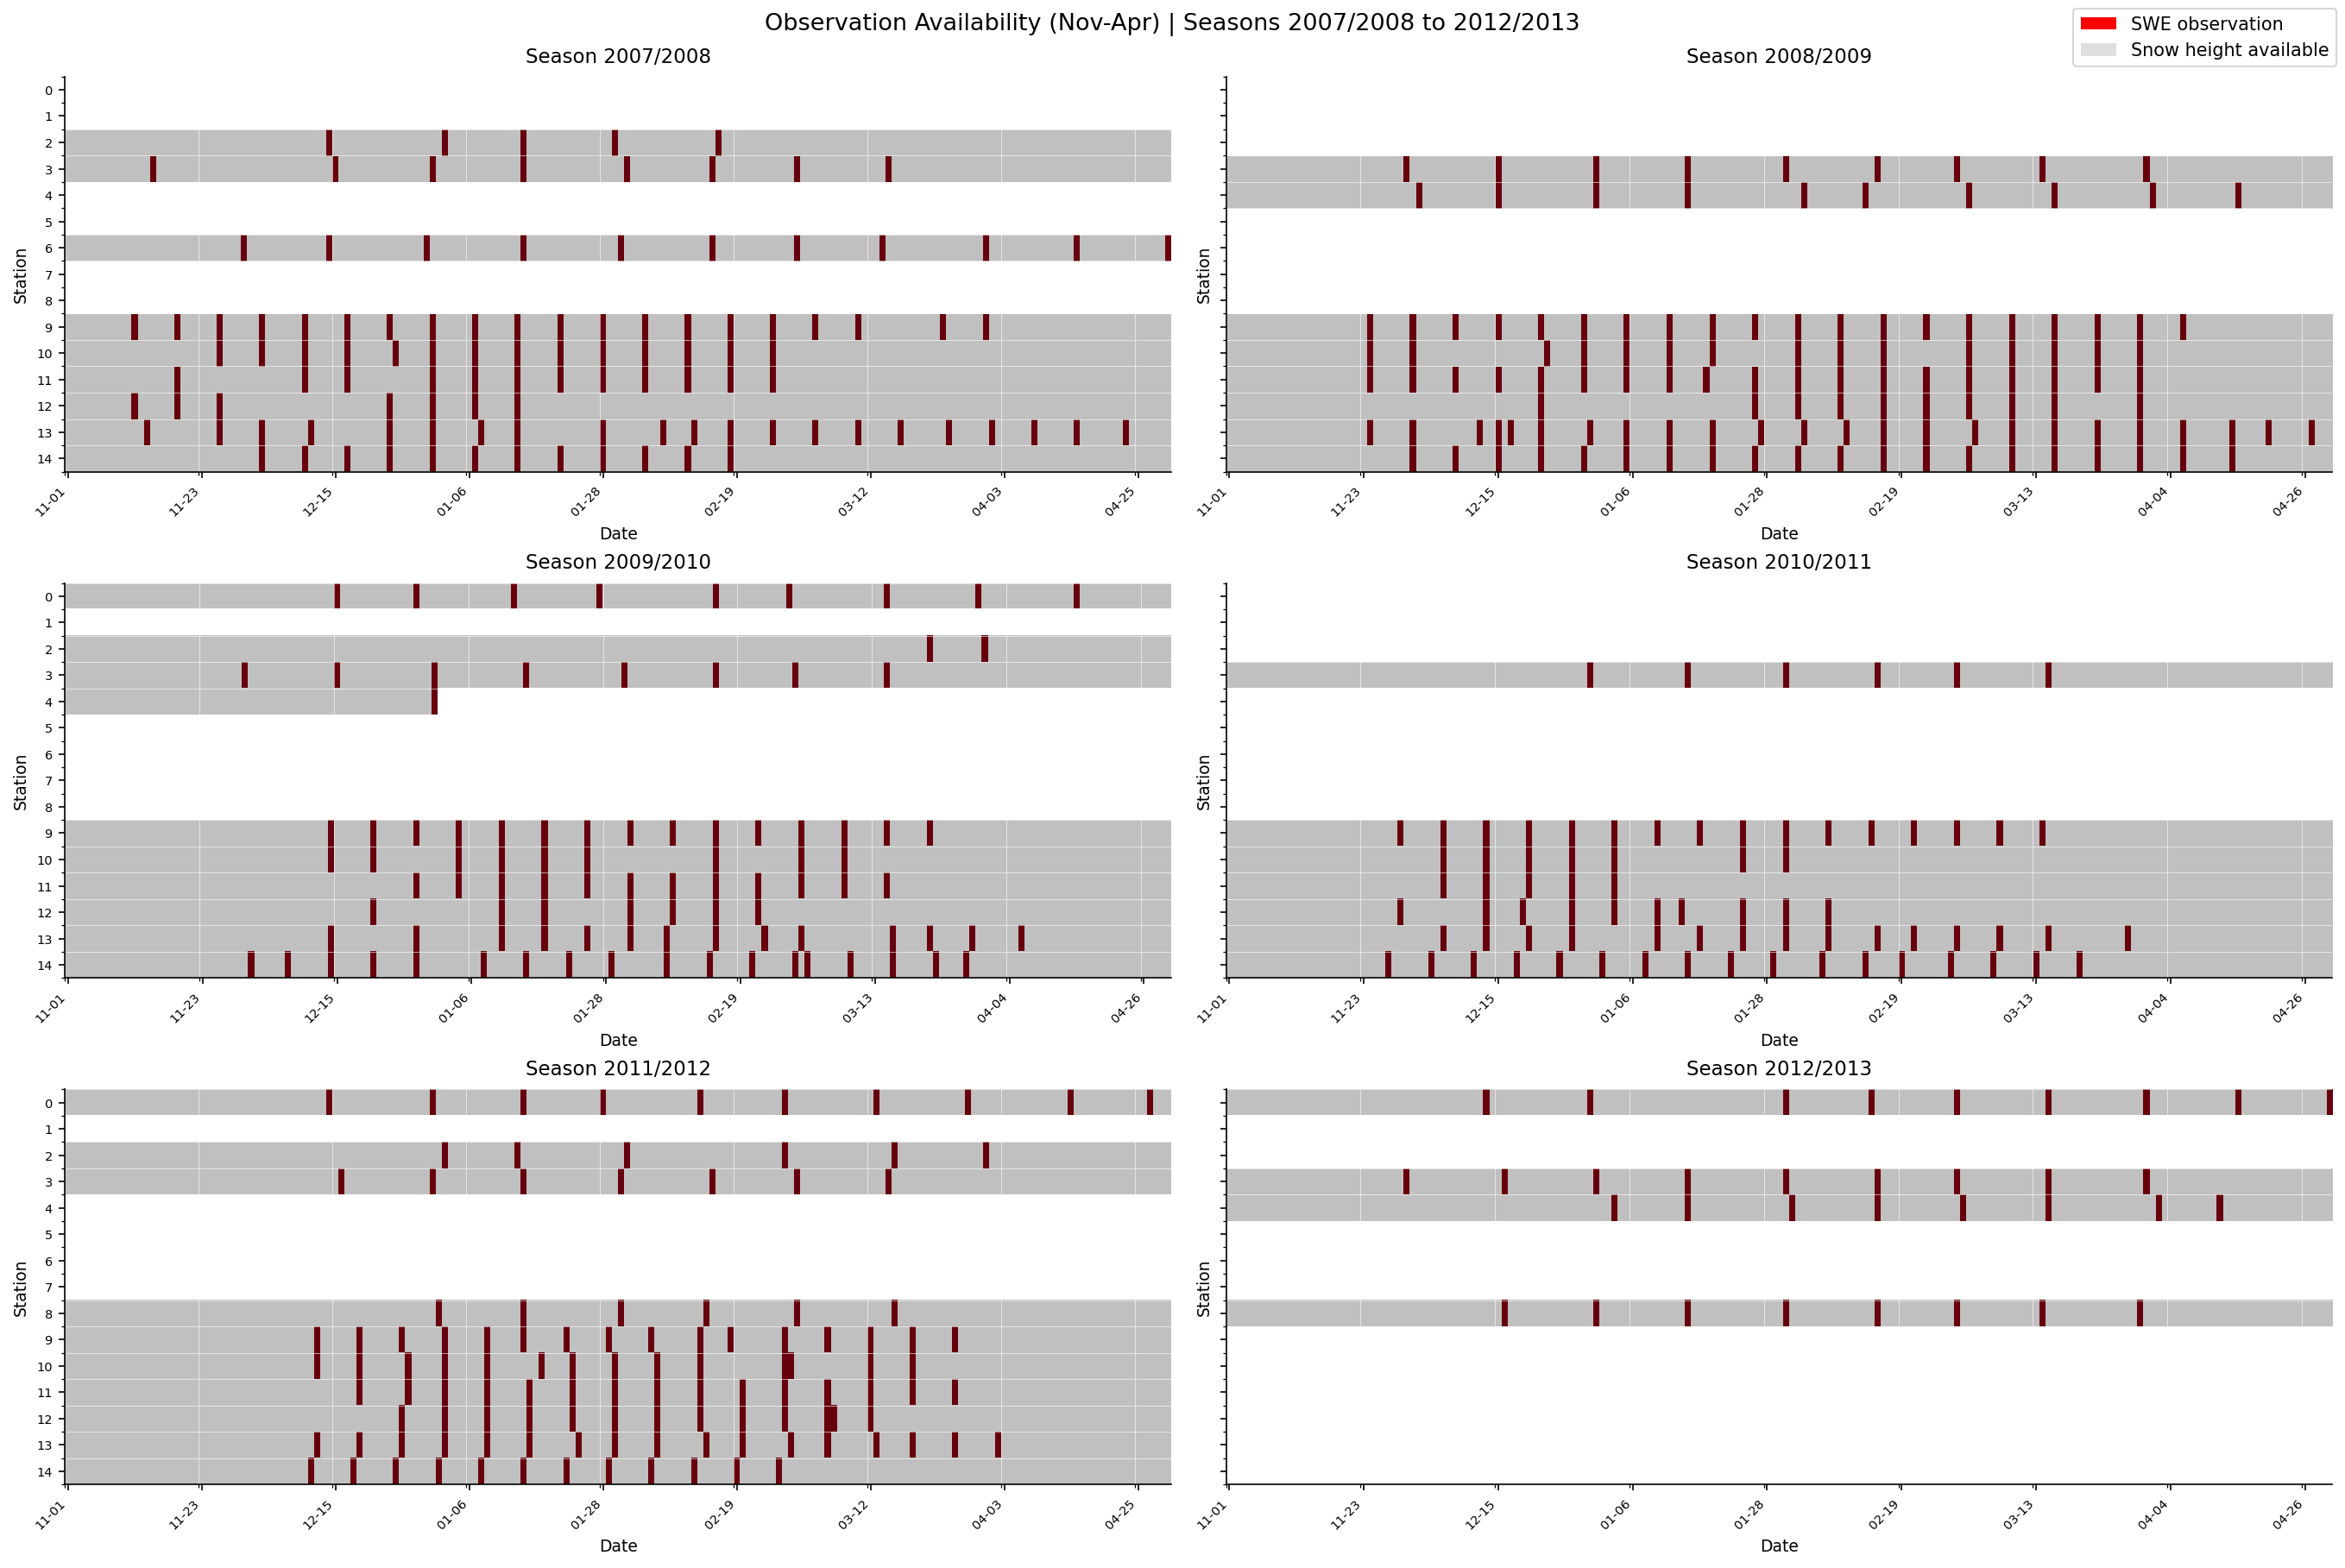

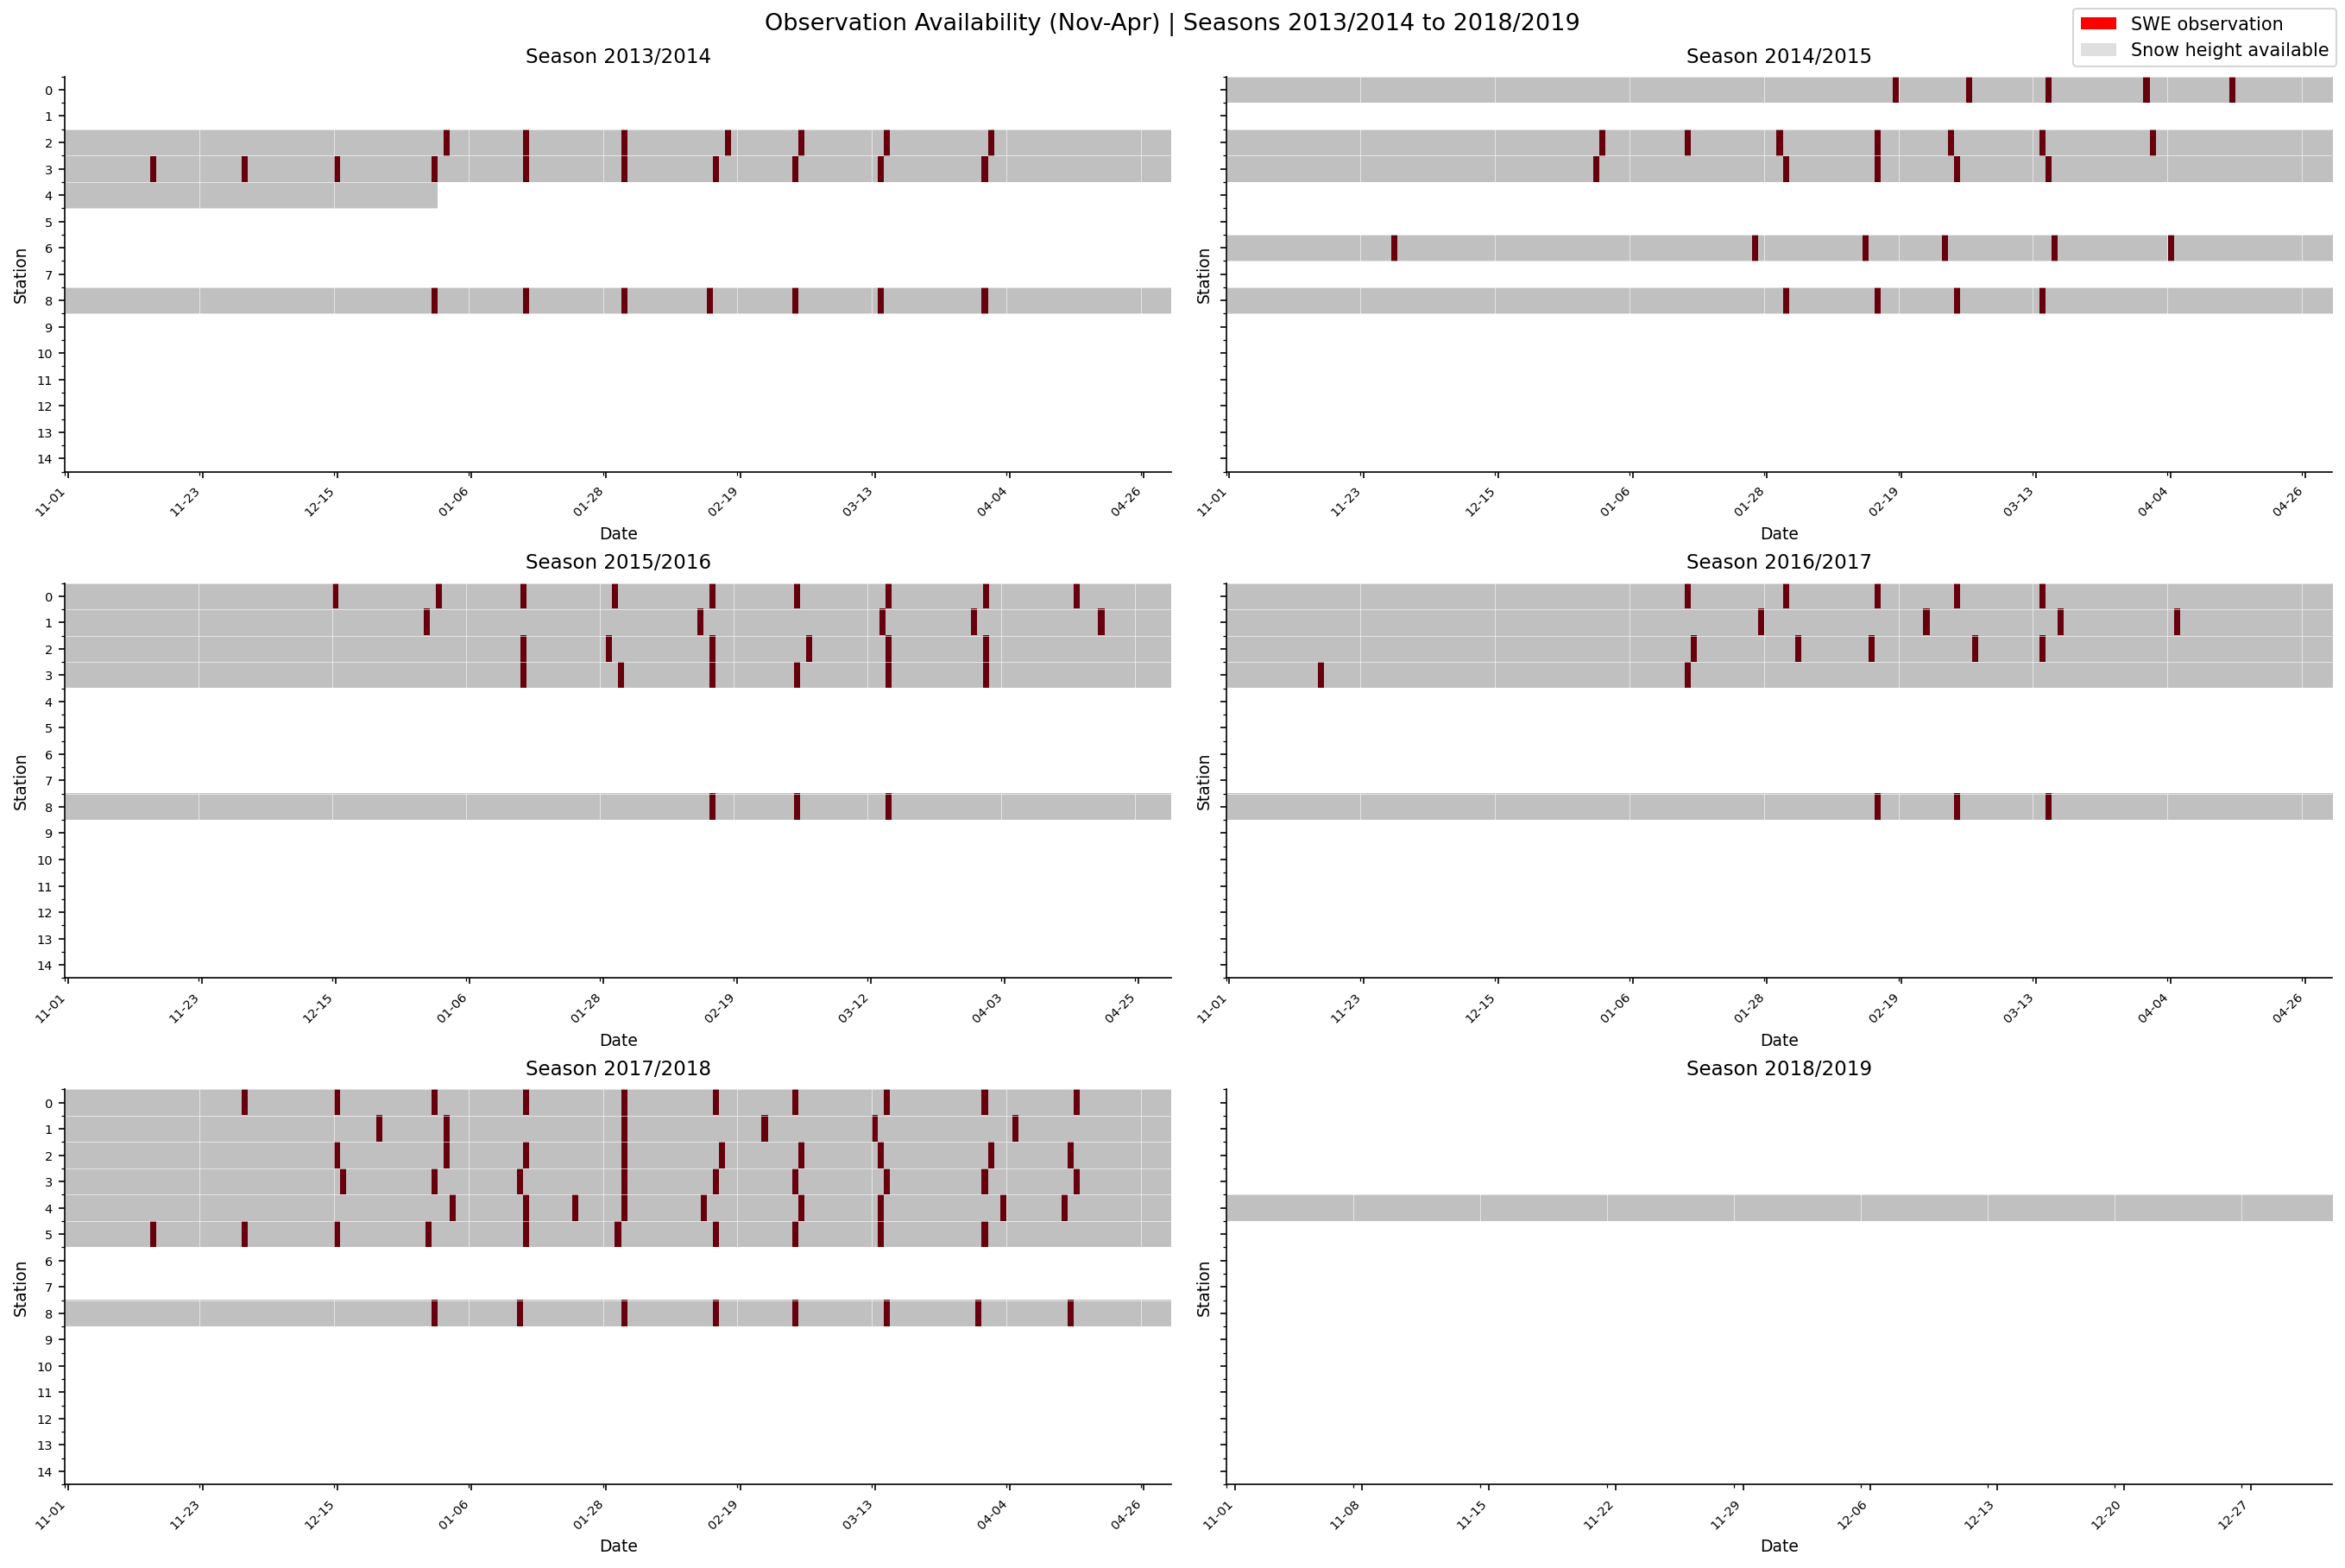

In [6]:
from matplotlib.patches import Patch

# Calendar-style availability plot (Nov 1 -> Apr 30): HS background, SWE overlay
# Render multiple compact figures so many seasons stay readable.

time_df = pd.DataFrame({"time": pd.to_datetime(ds["time"].values)})
time_df["year"] = time_df["time"].dt.year
time_df["month"] = time_df["time"].dt.month

def get_season(row):
    month = row["month"]
    year = row["year"]
    if month >= 11:
        return f"{year}/{year + 1}"
    if month <= 4:
        return f"{year - 1}/{year}"
    return None

time_df["season"] = time_df.apply(get_season, axis=1)
time_df = time_df[time_df["season"].notna()].copy()

swe_available = ds["SWE"].notnull().astype(int)
hs_available = ds["HS"].notnull().astype(int)
stations = ds["station"].values
seasons = sorted(time_df["season"].unique())

# Show up to 6 seasons per figure (2 columns x 3 rows).
panels_per_fig = 6
ncols = 2
nrows = 3

for start in range(0, len(seasons), panels_per_fig):
    page_seasons = seasons[start:start + panels_per_fig]
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(18, 12), sharey=True, constrained_layout=True
    )
    axes = axes.ravel()

    for i, season in enumerate(page_seasons):
        ax = axes[i]
        season_rows = time_df[time_df["season"] == season]
        season_times = season_rows["time"].values
        season_indices = season_rows.index.values

        hs_season = hs_available.isel(time=season_indices)
        swe_season = swe_available.isel(time=season_indices)

        hs_vals = hs_season.transpose("station", "time").values
        swe_vals = swe_season.transpose("station", "time").values

        ax.imshow(
            hs_vals,
            aspect="auto",
            cmap="Greys",
            interpolation="nearest",
            vmin=0,
            vmax=1,
            alpha=0.25,
        )

        swe_masked = np.ma.masked_where(swe_vals == 0, swe_vals)
        ax.imshow(
            swe_masked,
            aspect="auto",
            cmap="Reds",
            interpolation="nearest",
            vmin=0,
            vmax=1,
            alpha=1.0,
        )

        ax.set_yticks(np.arange(len(stations)))
        ax.set_yticklabels(stations, fontsize=7)

        n_times = len(season_times)
        step = max(n_times // 8, 1)
        xt = np.arange(0, n_times, step)
        ax.set_xticks(xt)
        ax.set_xticklabels(
            [pd.Timestamp(t).strftime("%m-%d") for t in season_times[::step]],
            rotation=45,
            ha="right",
            fontsize=7,
        )

        ax.set_xlabel("Date", fontsize=9)
        ax.set_ylabel("Station", fontsize=9)
        ax.set_title(f"Season {season}", fontsize=11, pad=8)

        ax.set_xticks(np.arange(-0.5, n_times, step), minor=True)
        ax.set_yticks(np.arange(-0.5, len(stations), 1), minor=True)
        ax.grid(which="minor", color="white", linestyle="-", linewidth=0.4, alpha=0.7)

    for j in range(len(page_seasons), len(axes)):
        axes[j].set_visible(False)

    legend_elements = [
        Patch(facecolor="red", alpha=1.0, label="SWE observation"),
        Patch(facecolor="gray", alpha=0.25, label="Snow height available"),
    ]
    fig.legend(handles=legend_elements, loc="upper right", fontsize=10)
    fig.suptitle(
        f"Observation Availability (Nov-Apr) | Seasons {page_seasons[0]} to {page_seasons[-1]}",
        fontsize=13,
    )
    plt.show()